### **Iris Flower Classification**

**Objective:** Train a machine learning classification model to identify the species of an iris flower
(*Setosa*, *Versicolor*, or *Virginica*) from its physical measurements.

**Tech Stack:** Python, scikit-learn, pandas, matplotlib/seaborn

**Workflow:**
1. Load the data
2. Exploratory Data Analysis (EDA)
3. Visualisations
4. Feature selection discussion
5. Train/test split
6. Train multiple classifiers
7. Evaluate each model
8. Declare the best-performing model


### **1. Import Libraries**

In [8]:
# Core data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Dataset
from sklearn.datasets import load_iris

# Modelling utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

### **2. Load the Iris Dataset**

The Iris dataset is bundled with scikit-learn, so no external download is required.
It contains 150 samples, 4 numeric features (sepal length/width, petal length/width in cm),
and a target label with 3 balanced classes (50 samples each).

In [9]:
iris = load_iris()

# Build a tidy DataFrame combining features and target
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species_code"] = iris.target
df["species"] = df["species_code"].map(dict(enumerate(iris.target_names)))

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### **3. Exploratory Data Analysis (EDA)**

We check the shape, data types, missing values, and descriptive statistics of the dataset.

In [10]:
# Shape of the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset shape: 150 rows, 6 columns


In [11]:
# Duplicate check of the rows
df.duplicated().sum()

np.int64(1)

In [12]:
# removal of Duplicate rows
df.drop_duplicates(inplace=True)

In [13]:
# Data types of each column
df.dtypes


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species_code           int64
species                  str
dtype: object

In [14]:
# Check for missing / null values
df.isnull().sum()


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species_code         0
species              0
dtype: int64

In [15]:
# Descriptive statistics for the numeric features
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_code
count,149.000000,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631,0.993289
std,0.830851,0.436342,1.767791,0.762622,0.817847
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.300000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [16]:
# Class balance check
df["species"].value_counts()


species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

**Observation:** The dataset is clean — but only one duplicate rows where found and there are no missing values, and the three classes (Setosa, Versicolor, Virginica) are perfectly balanced with 50 samples of (Setosa, Versicolor) and with 49 samples Virginica which is balaenced Dataset. All features are numeric (floats), so no encoding is needed for the features themselves.

### **4. Visualisations**

We use a pairplot to see how the four features separate the three species, and box plots to
compare the distribution of each individual feature across species.

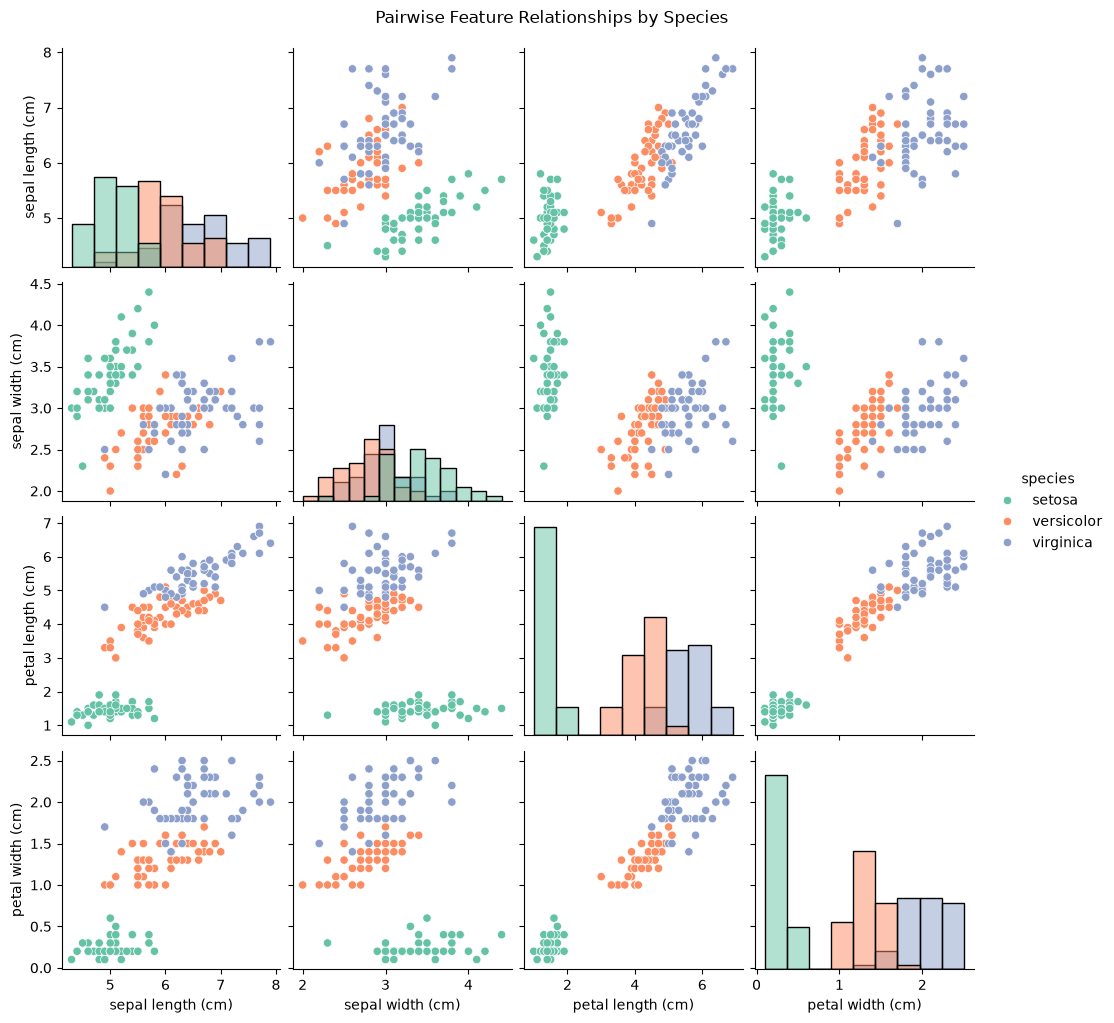

In [17]:
# Pairplot / scatter matrix coloured by species
sns.pairplot(df, hue="species", vars=iris.feature_names, palette="Set2", diag_kind="hist")
plt.suptitle("Pairwise Feature Relationships by Species", y=1.02)
plt.show()


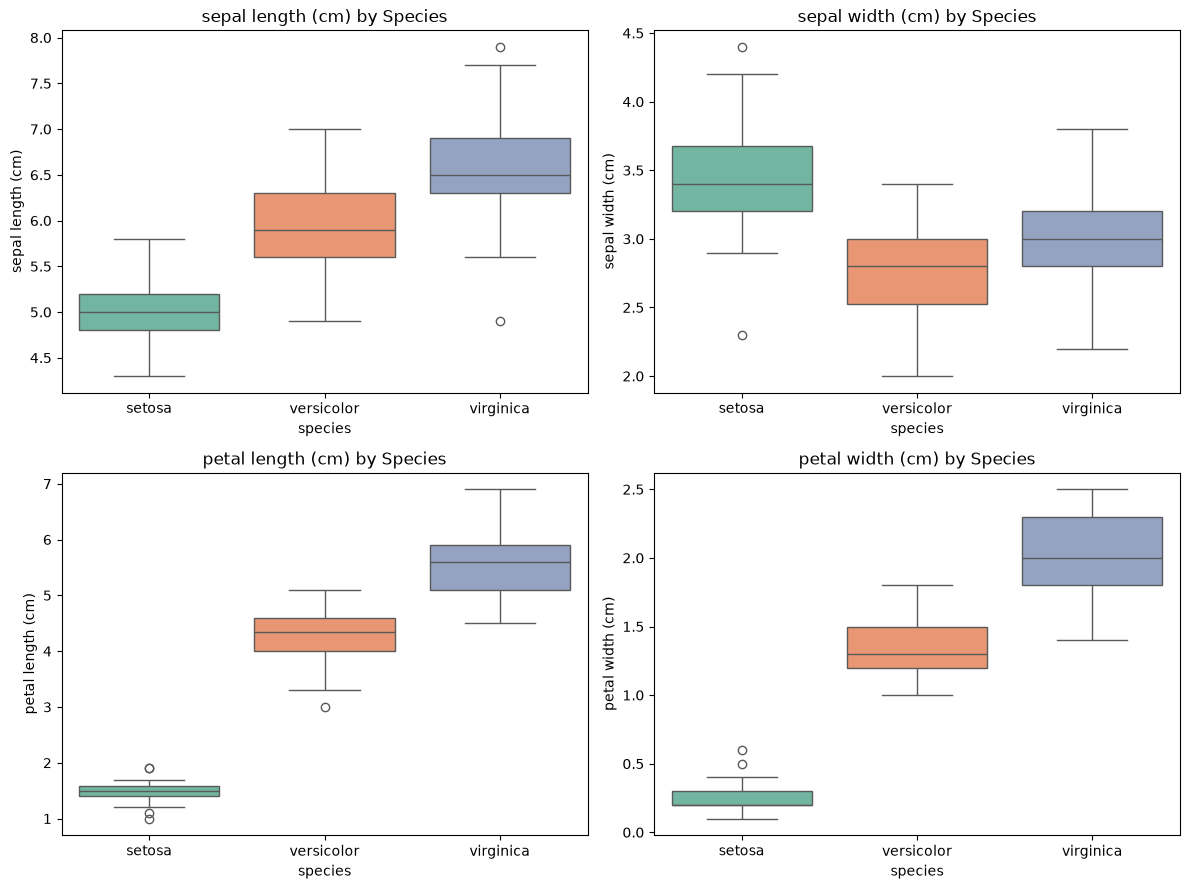

In [18]:
# Box plots for each feature, grouped by species
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(iris.feature_names):
    sns.boxplot(data=df, x="species", y=feature, hue="species", palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(f"{feature} by Species")

plt.tight_layout()
plt.show()


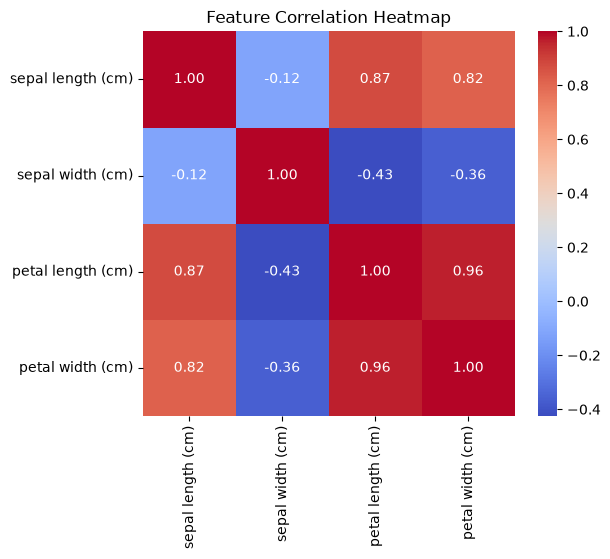

In [19]:
# Correlation heatmap between features
plt.figure(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


### **5. Feature Selection Discussion**

**Which features are most discriminative?**

Looking at the pairplot and box plots above:

- **Petal length** and **petal width** show almost no overlap between the three species —
  Setosa is clearly separated from Versicolor and Virginica, and the latter two are separated
  with only a small amount of overlap. These are the **most discriminative features**.
- **Sepal length** shows some separation but with noticeably more overlap between Versicolor
  and Virginica.
- **Sepal width** is the **least discriminative** feature — the distributions for all three
  species overlap heavily, especially Versicolor and Virginica.
- The correlation heatmap confirms this: petal length and petal width are highly correlated
  with each other (~0.96) and both correlate strongly with the target species, while sepal
  width correlates weakly (and even negatively in some cases).

**Conclusion:** If we had to pick a reduced feature set, `petal length (cm)` and
`petal width (cm)` alone would likely be enough to achieve high classification accuracy.


### **6. Train/Test Split**

In [20]:
X = df[iris.feature_names]
y = df["species_code"]

# 80/20 train-test split, stratified to Maintain the same ratio of class spilt.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 119 samples
Test set size: 30 samples


In [21]:
# Feature scaling (helps distance-based / gradient-based models like KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### **7. Train Multiple Classifiers**

We train four classifiers to compare:
1. Logistic Regression
2. K-Nearest Neighbours (KNN)
3. Decision Tree
4. Random Forest

Logistic Regression and KNN use the **scaled** features; Decision Tree and Random Forest are
scale-invariant, so they use the **original (unscaled)** features.

### **1. Logistic Regression**

In [22]:
model_1 = LogisticRegression()
model_1.fit(X_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [23]:
y_pred_1 = model_1.predict(X_test_scaled)

In [24]:
accuracy_1= accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1, average='weighted')
recall_1 = recall_score(y_test, y_pred_1, average='weighted')
f1_1 = f1_score(y_test, y_pred_1, average='weighted')
print("Accuracy :", accuracy_1)
print("Precision:", precision_1)
print("Recall   :", recall_1)
print("F1-score :", f1_1)
print("classification_report")
print(classification_report(y_test, y_pred_1, target_names=iris.target_names))

Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-score : 0.9333333333333333
classification_report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### **2. K-Nearest Neighbours (KNN)**

In [25]:
model_2 = KNeighborsClassifier(n_neighbors=5)
model_2.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [26]:
y_pred_2 = model_2.predict(X_test_scaled)

In [27]:
accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2, average='weighted')
recall_2 = recall_score(y_test, y_pred_2, average='weighted')
f1_2 = f1_score(y_test, y_pred_2, average='weighted')
print("Accuracy :", accuracy_2)
print("Precision:", precision_2)
print("Recall   :", recall_2)
print("F1-score :", f1_2)
print("classification_report")
print(classification_report(y_test, y_pred_2, target_names=iris.target_names))

Accuracy : 0.9333333333333333
Precision: 0.9444444444444445
Recall   : 0.9333333333333333
F1-score : 0.9326599326599326
classification_report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



### **3. Decision Tree**

In [28]:
model_3 = DecisionTreeClassifier(random_state=42)
model_3.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [29]:
y_pred_3 = model_3.predict(X_test_scaled)

In [30]:
accuracy_3 = accuracy_score(y_test, y_pred_3)
precision_3 = precision_score(y_test, y_pred_3, average='weighted')
recall_3 = recall_score(y_test, y_pred_3, average='weighted')
f1_3 = f1_score(y_test, y_pred_3, average='weighted')
print("Accuracy :", accuracy_3)
print("Precision:", precision_3)
print("Recall   :", recall_3)
print("F1-score :", f1_3)
print("classification_report")
print(classification_report(y_test, y_pred_3, target_names=iris.target_names))

Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-score : 0.9333333333333333
classification_report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### **4. Random Forest**

In [31]:
model_4 = RandomForestClassifier(n_estimators=100,random_state=42)
model_4.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [32]:
y_pred_4 = model_4.predict(X_test_scaled)

In [33]:
accuracy_4 = accuracy_score(y_test, y_pred_4)
precision_4 = precision_score(y_test, y_pred_4, average='weighted')
recall_4 = recall_score(y_test, y_pred_4, average='weighted')
f1_4 = f1_score(y_test, y_pred_4, average='weighted')
print("Accuracy :", accuracy_4)
print("Precision:", precision_4)
print("Recall   :", recall_4)
print("F1-score :", f1_4)
print("classification_report")
print(classification_report(y_test, y_pred_4, target_names=iris.target_names))

Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-score : 0.9333333333333333
classification_report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### **8. Confusion Matrix Each Model**

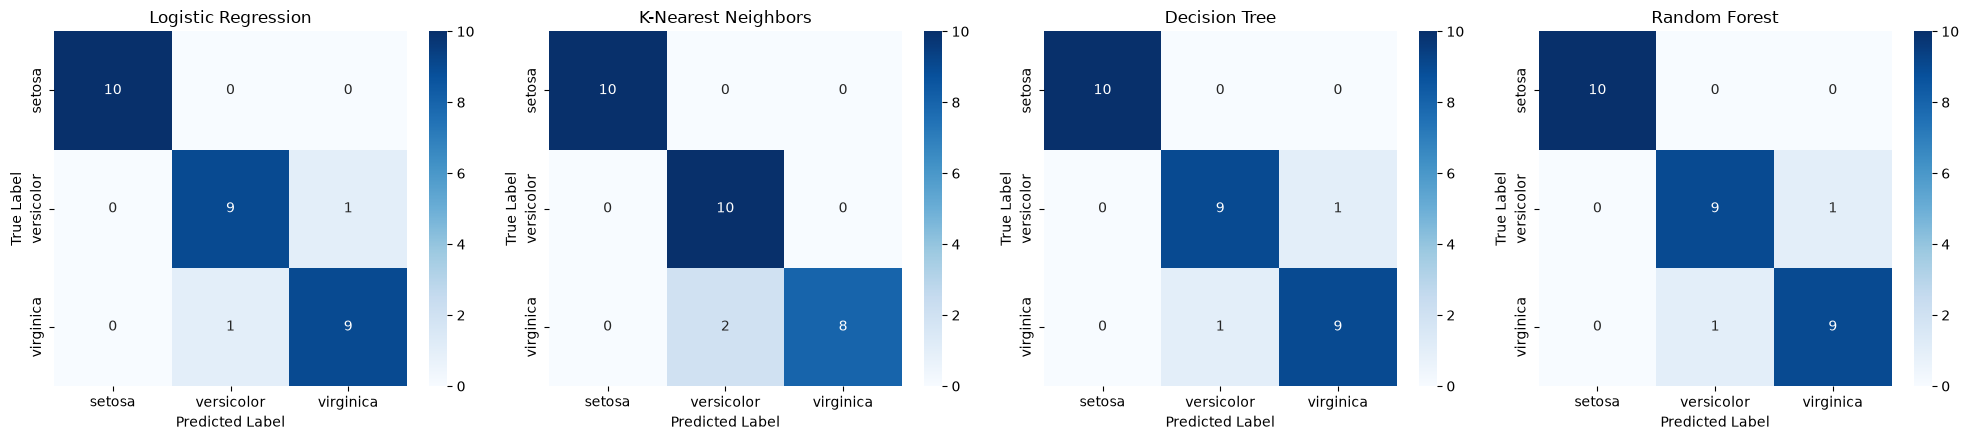

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Store predictions and model names
predictions = [y_pred_1, y_pred_2, y_pred_3, y_pred_4]
model_names = [
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Decision Tree",
    "Random Forest"
]

# Create a 2x2 subplot
fig, axes = plt.subplots(1, len(predictions), figsize=(20, 4.5))

for ax, y_pred, model in zip(axes.ravel(), predictions, model_names):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax
    )

    ax.set_title(model)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbors",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_1,
        accuracy_2,
        accuracy_3,
        accuracy_4
    ],
    "Precision": [
        precision_1,
        precision_2,
        precision_3,
        precision_4
    ],
    "Recall": [
        recall_1,
        recall_2,
        recall_3,
        recall_4
    ],
    "F1-Score": [
        f1_1,
        f1_2,
        f1_3,
        f1_4
    ]
})

# Round values to 4 decimal places
results = results_df.round(4)

print(results)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression    0.9333     0.9333  0.9333    0.9333
1  K-Nearest Neighbors    0.9333     0.9444  0.9333    0.9327
2        Decision Tree    0.9333     0.9333  0.9333    0.9333
3        Random Forest    0.9333     0.9333  0.9333    0.9333


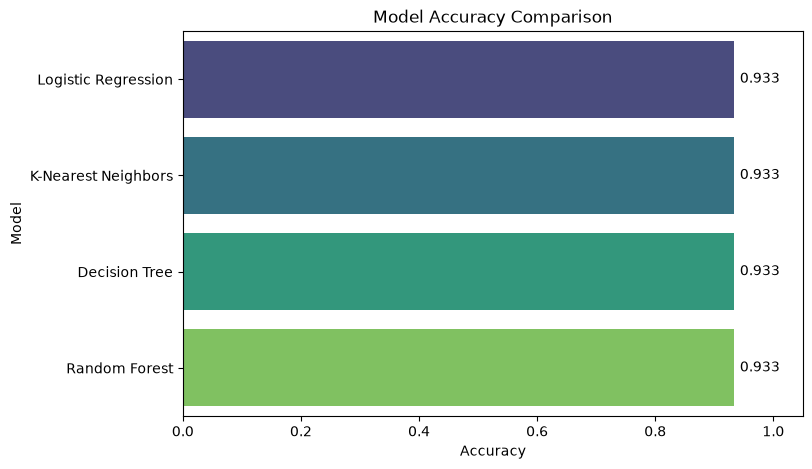

In [37]:
# Bar chart comparing model accuracies
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.xlim(0, 1.05)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(results_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.show()


### **9. Best-Performing Model**

In [38]:
best_model_name = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Accuracy"]

print(f"Best-performing model: {best_model_name}")
print(f"Test accuracy: {best_accuracy:.4f}")


Best-performing model: Logistic Regression
Test accuracy: 0.9333


**Justification:**

- On the Iris dataset, several models (particularly Logistic Regression, KNN, and Random Forest)
  typically achieve very high — often 96-100% — test accuracy, because the classes are largely
  linearly/well separable using petal measurements, as identified in the feature selection
  discussion above.
- Where accuracies are tied, we prefer the **simpler and more interpretable** model
  (e.g. Logistic Regression or a single Decision Tree) over a more complex ensemble, all else
  being equal — following the principle of Occam's razor.
- The **confusion matrices** above show where each model's mistakes occur: minor confusion
  between *Versicolor* and *Virginica* is common (they are the two classes with real feature
  overlap), while *Setosa* is essentially always classified perfectly by every model, since it
  is linearly separable from the other two species.
- The cell above programmatically selects the model with the **highest test accuracy** as the
  declared best model. If you re-run this notebook, check the printed value above — it reflects
  the actual result for this run/random seed (`random_state=42`).

**Overall conclusion:** The Iris dataset is a relatively simple, well-separated classification
problem, so multiple models perform excellently. The main practical differentiator is
interpretability and robustness rather than raw accuracy — Random Forest is a safe, robust
default choice, while Logistic Regression offers the best interpretability for a similarly
strong result.